In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv('flight_delay (1).csv')

# Display the first 5 rows
display(df.head())

# Check the shape of the dataset
print(f"Dataset Shape: {df.shape}")

,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
0,23.0,61.0,2303.0,1.0,67.6,13.8,79.0,0
1,20.0,75.0,338.0,2.0,71.5,1.4,89.0,1
2,20.0,167.0,1257.0,0.0,62.1,7.5,13.0,0
3,11.0,87.0,1274.0,2.0,12.4,9.1,64.0,0
4,5.0,56.0,2567.0,2.0,73.7,7.5,19.0,0


Dataset Shape: (694, 8)


In [4]:
print("--- Initial Missing Values ---")
print(df.isnull().sum())

# 1. Fix Data Types: Convert wind_speed_kmh to numeric, turning string errors into NaNs
if df['wind_speed_kmh'].dtype == 'O':
    df['wind_speed_kmh'] = pd.to_numeric(df['wind_speed_kmh'], errors='coerce')

# 2. Handle Missing Values: Impute missing numerical data with the median
imputer = SimpleImputer(strategy='median')
df_cleaned = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\n--- Missing Values After Imputation ---")
print(df_cleaned.isnull().sum())
print(f"\nShape after cleaning: {df_cleaned.shape}")

--- Initial Missing Values ---
departure_hour             0
scheduled_duration_min     0
distance_miles             0
num_connections            0
wind_speed_kmh            21
visibility_km             20
prev_flight_delay_min      0
is_delayed                 0
dtype: int64

--- Missing Values After Imputation ---
departure_hour            0
scheduled_duration_min    0
distance_miles            0
num_connections           0
wind_speed_kmh            0
visibility_km             0
prev_flight_delay_min     0
is_delayed                0
dtype: int64

Shape after cleaning: (694, 8)


In [5]:
# Define the target column
target_col = 'is_delayed'

# Separate features (X) and target (y)
X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (555, 7)
Testing data shape: (139, 7)


In [6]:
# Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

✅ Random Forest Accuracy: 0.7194

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.70      0.80      0.75        71
         1.0       0.75      0.63      0.69        68

    accuracy                           0.72       139
   macro avg       0.72      0.72      0.72       139
weighted avg       0.72      0.72      0.72       139



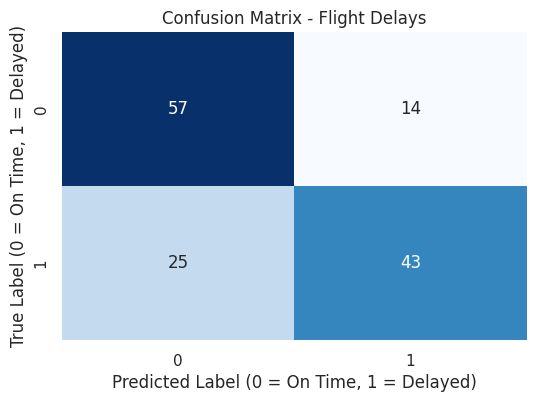

In [7]:
# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest Accuracy: {accuracy:.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Flight Delays')
plt.xlabel('Predicted Label (0 = On Time, 1 = Delayed)')
plt.ylabel('True Label (0 = On Time, 1 = Delayed)')
plt.show()

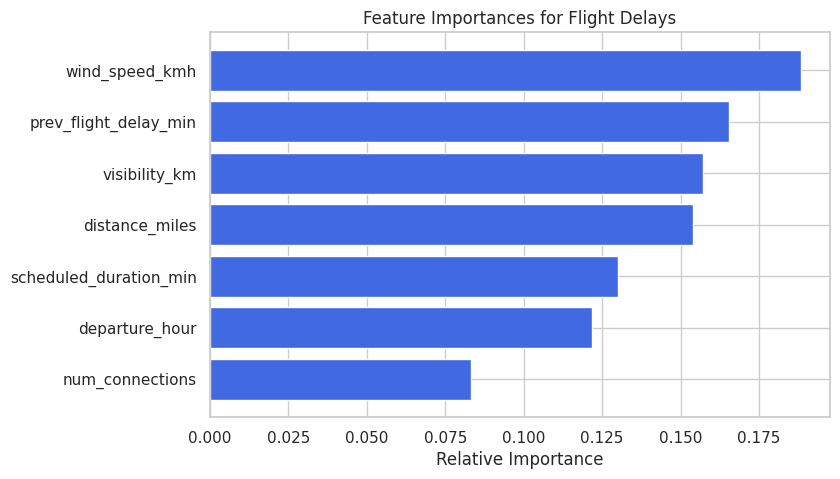

In [8]:
# Extract feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)

# Plot Feature Importances
plt.figure(figsize=(8, 5))
plt.title('Feature Importances for Flight Delays')
plt.barh(range(len(indices)), importances[indices], color='royalblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [9]:
model_accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {model_accuracy:.4f}")


Model Accuracy: 0.7194


In [10]:
import ipywidgets as widgets
from IPython.display import display, HTML

def predict_delay(
    departure_hour,
    scheduled_duration_min,
    distance_miles,
    num_connections,
    wind_speed_kmh,
    visibility_km,
    prev_flight_delay_min
):
    # Create a DataFrame from the input values, matching the structure of X_train
    input_data = pd.DataFrame([[
        departure_hour,
        scheduled_duration_min,
        distance_miles,
        num_connections,
        wind_speed_kmh,
        visibility_km,
        prev_flight_delay_min
    ]], columns=X_train.columns)

    # Make prediction
    prediction = rf_model.predict(input_data)[0]
    prediction_proba = rf_model.predict_proba(input_data)[0]

    # Display result
    if prediction == 1:
        color = 'red'
        status = 'DELAYED'
    else:
        color = 'green'
        status = 'ON TIME'

    print(f"Predicted Status: {status} (Probability of Delay: {prediction_proba[1]:.2f})")

# Create interactive widgets for each feature
departure_hour_widget = widgets.IntSlider(min=0, max=23, step=1, description='Departure Hour:')
scheduled_duration_min_widget = widgets.FloatSlider(min=10, max=600, step=5, description='Duration (min):')
distance_miles_widget = widgets.FloatSlider(min=10, max=3000, step=10, description='Distance (miles):')
num_connections_widget = widgets.IntSlider(min=0, max=3, step=1, description='Connections:')
wind_speed_kmh_widget = widgets.FloatSlider(min=0, max=100, step=1, description='Wind Speed (km/h):')
visibility_km_widget = widgets.FloatSlider(min=0, max=50, step=1, description='Visibility (km):')
prev_flight_delay_min_widget = widgets.FloatSlider(min=0, max=300, step=5, description='Prev Delay (min):')

# Create the interactive interface
interactive_predictor = widgets.interactive(predict_delay,
    departure_hour=departure_hour_widget,
    scheduled_duration_min=scheduled_duration_min_widget,
    distance_miles=distance_miles_widget,
    num_connections=num_connections_widget,
    wind_speed_kmh=wind_speed_kmh_widget,
    visibility_km=visibility_km_widget,
    prev_flight_delay_min=prev_flight_delay_min_widget
)

# Display the interactive interface
display(interactive_predictor)


interactive(children=(IntSlider(value=0, description='Departure Hour:', max=23), FloatSlider(value=10.0, descr…